Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported.
pandas 2.2.2 | numpy 2.0.2
Dataset loaded: 55,121 encounters x 225 columns

First 3 rows:
   dep_name  esi   age  gender           ethnicity                race     lang     religion      maritalstatus employstatus  \
7         A  4.0  87.0  Female  Hispanic or Latino               Other    Other  Pentecostal            Widowed      Retired   
17        B  2.0  53.0    Male  Hispanic or Latino               Other  English     Catholic  Significant Other     Disabled   
40        A  2.0  49.0  Female        Non-Hispanic  White or Caucasian  English     Catholic            Married    Full Time   

   insurance_status disposition arrivalmode arrivalmonth arrivalday arrivalhour_bin previousdispo  triage_vital_hr  triage_vital_sbp  \
7          Medicare   Discharge         Car        March   Saturday           11-14         Admit             88

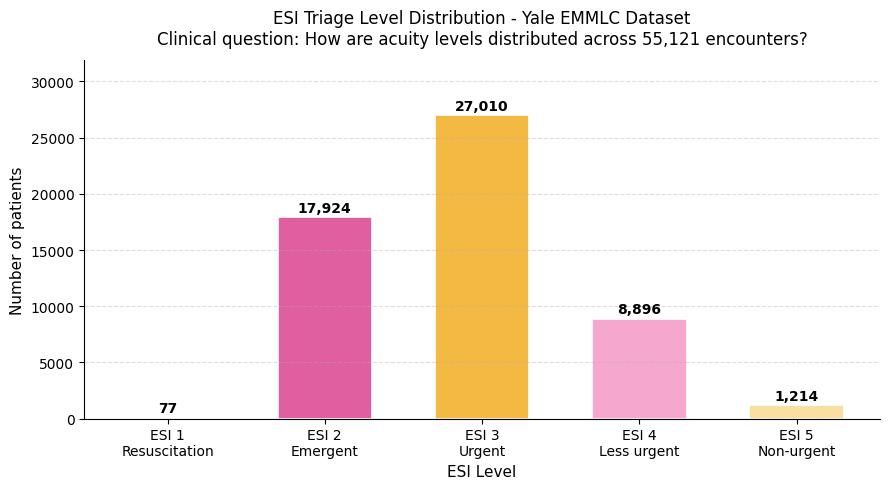

Saved: plot1_esi_distribution.png
Finding: ESI 2 and 3 dominate (81.5%). ESI 1 has only 77 patients, severe class imbalance.


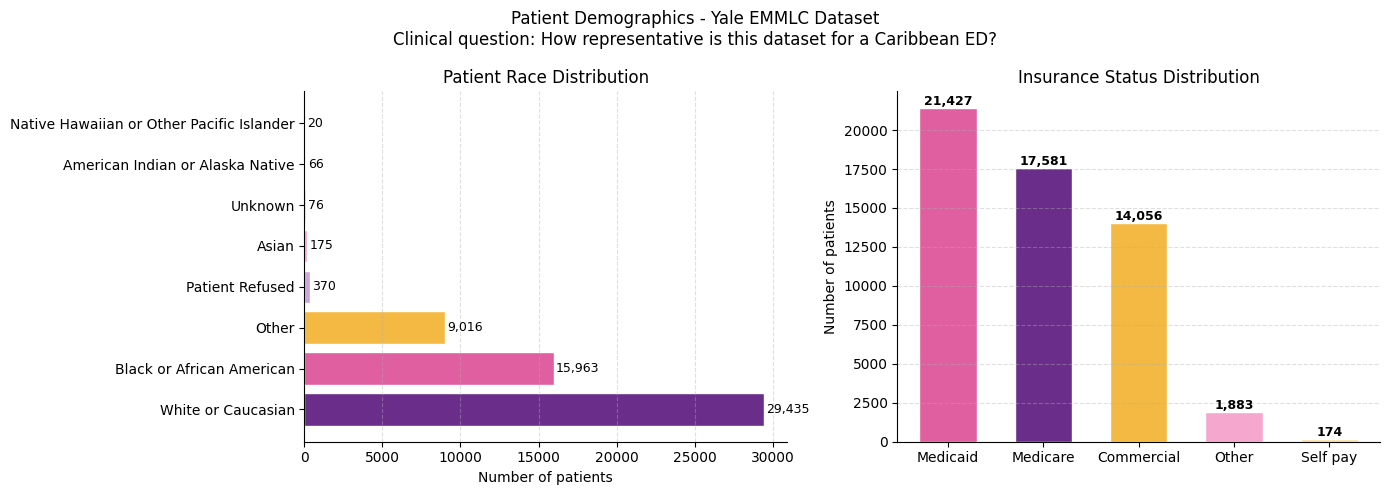

Saved: plot2_demographics.png
Finding: 53% White or Caucasian, 29% Black or African American.
Caribbean ED populations will differ, equity audit required before deployment.


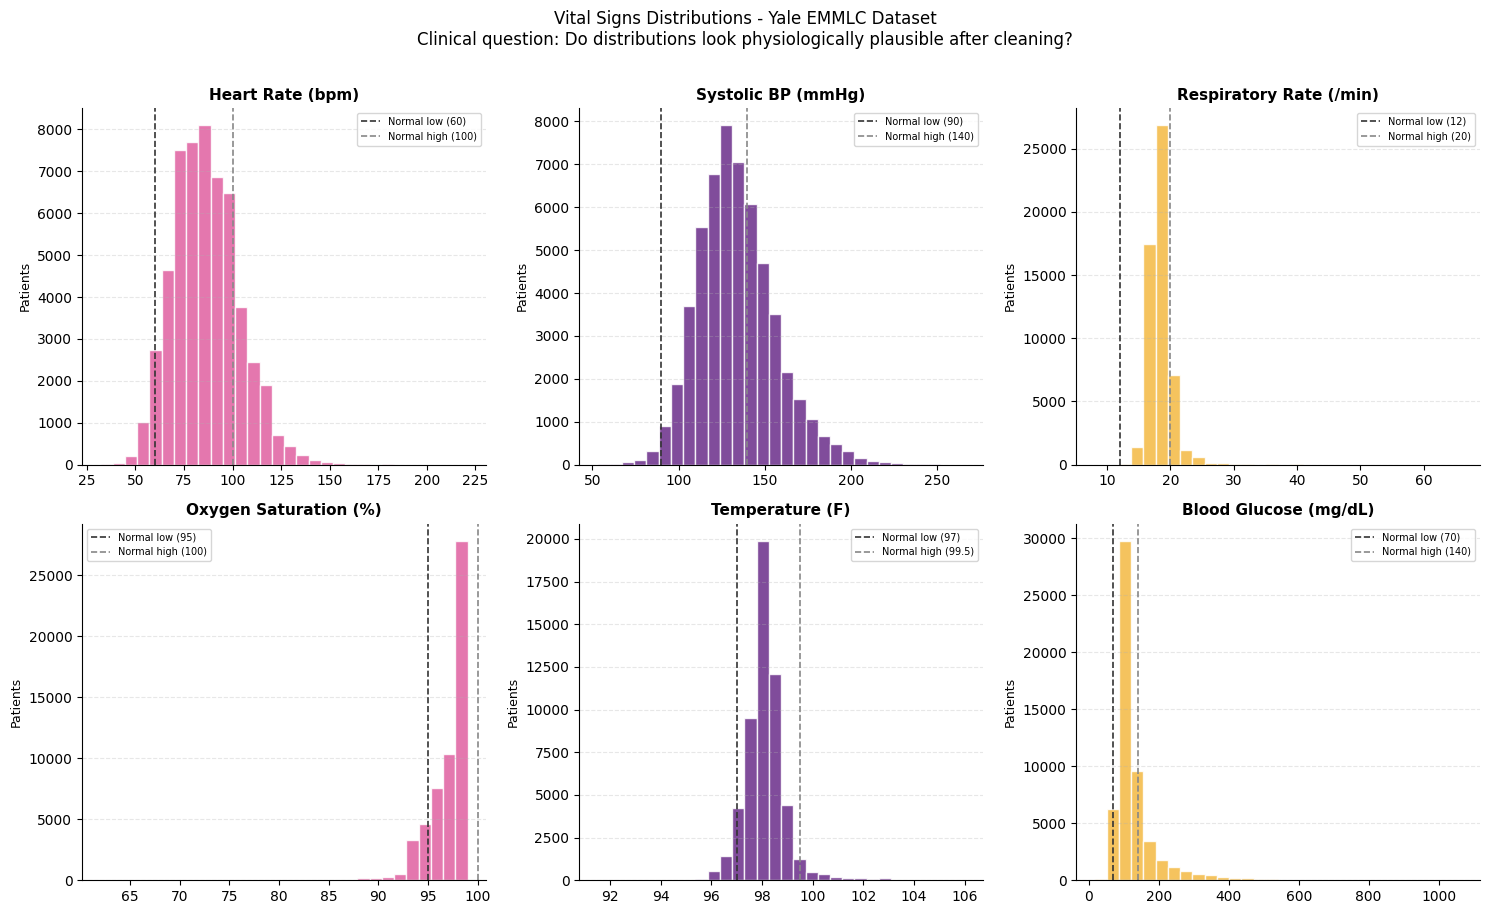

Saved: plot3_vitals_distributions.png
Finding: All vital sign distributions are physiologically plausible.
Note: Temperature mean 98.09F confirms this is Fahrenheit, not Celsius.


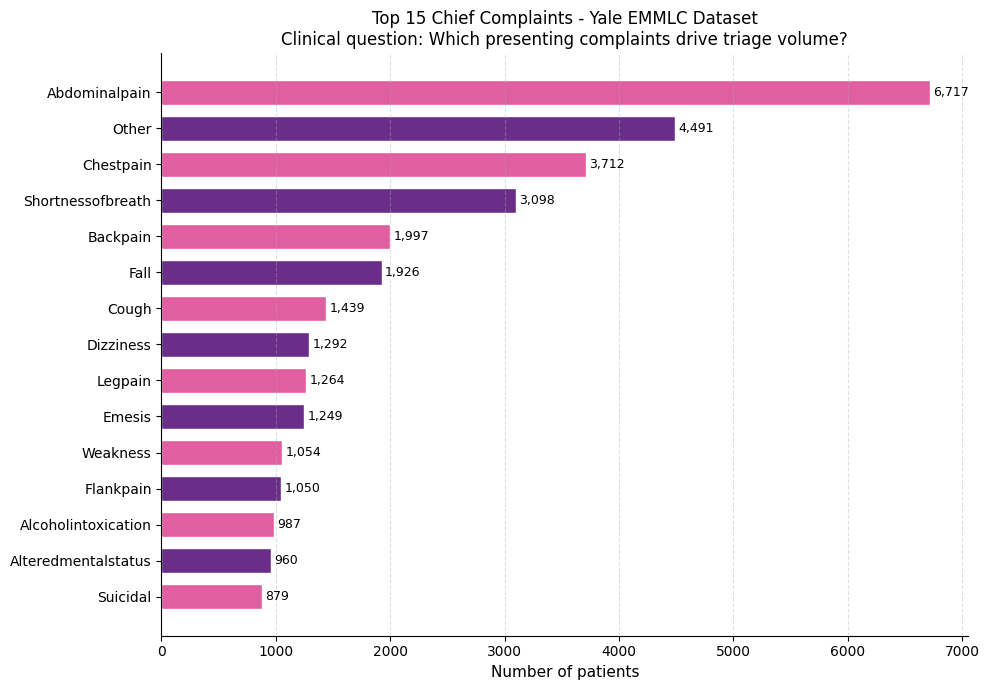

Saved: plot4_chief_complaints.png
Finding: Abdominal pain is the most common complaint (6,717 patients).
Chest pain (3,712) and shortness of breath (3,098) are high-acuity red-flag complaints.

FEASIBILITY MEMO OUTLINE - Week 5 Interim
To:      ED Board, Mercer General Hospital
From:    Ashi Baldie, CariSurg MedTech Pathways 2026
Re:      Yale EMMLC Triage Dataset Feasibility Assessment
Date:    4 July 2026

VERDICT 

This dataset is suitable for building a baseline triage classification
model, provided leakage columns are excluded and findings are not applied
to a Caribbean ED without local validation.


DATASET SUMMARY
- 55,121 emergency department encounters
- 225 features per encounter
- Patients aged 18-107, mean age 55 years
- 57.6% Female, 42.4% Male
- Race: 53.4% White, 29.0% Black or African American, 16.4% Other
- ESI distribution: ESI 2 (32.5%), ESI 3 (49.0%) dominate; ESI 1 = 0.1%
- 6 triage vital signs, 200 chief complaint flags, full demographics
- Zero missing values acr

In [7]:
# CariSurg MedTech Pathways - Week 5 Interim
# Week 5: Data Exploration - Clinical Data Literacy, Profiling
#         and Initial Visualisation
# Author: Ashi Baldie
# Dataset: Yale EMMLC Admission Prediction Triage
#          (yaleemmlc_admissionprediction_triage.csv)


# CELL 1 — SETUP: Mount Drive and import libraries
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

drive.mount('/content/drive')

# Colour palette: yellow, pink, purple
YELLOW  = '#F4B942'
PINK    = '#E05FA0'
PURPLE  = '#6A2D8A'
LIGHT_PURPLE = '#C9A6E0'
LIGHT_PINK   = '#F5A7CE'
LIGHT_YELLOW = '#FAE0A0'

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

print('Libraries imported.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')


# CELL 2 - LOAD DATA

# data path
DATA_PATH = '/content/drive/MyDrive/carisurg-portfolio/yaleemmlc_admissionprediction_triage.csv'

df = pd.read_csv(DATA_PATH, index_col=0)

print(f'Dataset loaded: {df.shape[0]:,} encounters x {df.shape[1]} columns')
print()
print('First 3 rows:')
print(df.head(3))


# CELL 3 - DEFINE COLUMN FAMILIES

TARGET = 'esi'   # Emergency Severity Index: 1 (most urgent) to 5 (least)

# Vital signs recorded at the triage desk on patient arrival
VITALS = [
    'triage_vital_hr',    # Heart rate (beats per minute)
    'triage_vital_sbp',   # Systolic blood pressure (mmHg)
    'triage_vital_dbp',   # Diastolic blood pressure (mmHg)
    'triage_vital_rr',    # Respiratory rate (breaths per minute)
    'triage_vital_o2',    # Oxygen saturation (%)
    'triage_vital_temp',  # Body temperature (FAHRENHEIT, not Celsius)
    'triage_glucose',     # Blood glucose (mg/dL)
]

# Demographic columns
DEMOGRAPHICS = [
    'age', 'gender', 'ethnicity', 'race', 'lang',
    'religion', 'maritalstatus', 'employstatus', 'insurance_status'
]

# Administrative / arrival details
ADMIN = ['dep_name', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin']

# LEAKAGE COLUMNS - known only AFTER the visit ends
LEAKAGE = ['disposition', 'previousdispo']

# Chief complaint flags: ~200 binary columns, one per complaint
CC_COLS = [c for c in df.columns if c.startswith('cc_')]

print(f'Target column:           {TARGET}')
print(f'Vital sign columns:      {len(VITALS)}')
print(f'Demographic columns:     {len(DEMOGRAPHICS)}')
print(f'Admin columns:           {len(ADMIN)}')
print(f'Leakage columns:         {len(LEAKAGE)} -> {LEAKAGE}')
print(f'Chief complaint columns: {len(CC_COLS)}')
print(f'Total columns:           {df.shape[1]}')


# CELL 4 - ESI TARGET DISTRIBUTION
# ESI - Emergency Severity Index. This is what we are trying to predict.

ESI_LABELS = {
    1: 'Resuscitation',
    2: 'Emergent',
    3: 'Urgent',
    4: 'Less urgent',
    5: 'Non-urgent'
}

esi_counts = df['esi'].value_counts().sort_index()
esi_pct = (esi_counts / len(df) * 100).round(1)

print('ESI (Triage Level) distribution:')
print('-' * 45)
for level in esi_counts.index:
    label = ESI_LABELS[int(level)]
    n = esi_counts[level]
    pct = esi_pct[level]
    print(f'  ESI {int(level)} ({label:<14}): {n:>7,}  ({pct:>4}%)')

print(f'\nTotal encounters: {len(df):,}')
print(f'Missing ESI labels: {df["esi"].isnull().sum()}')
print()
print('Key insight: ESI 2 and 3 together account for 81.5% of encounters.')
print('ESI 1 (most critical) represents only 0.1%, extreme class imbalance.')


# CELL 5 - MISSINGNESS PROFILE

# Check missingness across all columns
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# Shows only columns that actually have missing values
missing_nonzero = missing_report[missing_report['missing_count'] > 0]

print('Missingness Report')
if len(missing_nonzero) == 0:
    print('No missing values found across all 225 columns.')
    print('This is unusually clean for a clinical dataset.')
    print('Note: "clean" data from a single site may still carry')
    print('systematic bias, absence of NaN does not mean absence of issues.')
else:
    print(missing_nonzero.head(20))

print()
print('Vital signs missingness:')
for v in VITALS:
    n = df[v].isnull().sum()
    print(f'  {v:<25}: {n} missing')

print()
print('Admin missingness:')
for a in ADMIN:
    n = df[a].isnull().sum()
    print(f'  {a:<25}: {n} missing')
    if n > 0:
        print(f'    {df[a].value_counts(dropna=False)}')
        print()

print()
print('Demographic missingness:')
for d in DEMOGRAPHICS:
    n = df[d].isnull().sum()
    print(f'  {d:<25}: {n} missing')
    if n > 0:
        print(f'    {df[d].value_counts(dropna=False)}')
        print()


# CELL 6 - OUTLIER DETECTION
# Values outside these bounds are data entry errors, not real clinical readings.

PLAUSIBLE = {
    'triage_vital_hr':  (20, 250, 'bpm',    'Heart rate'),
    'triage_vital_sbp': (50, 300, 'mmHg',   'Systolic BP'),
    'triage_vital_dbp': (20, 200, 'mmHg',   'Diastolic BP'),
    'triage_vital_rr':  (4,  60,  '/min',   'Respiratory rate'),
    'triage_vital_o2':  (50, 100, '%',      'Oxygen saturation'),
    'triage_vital_temp':(86, 110, 'F',      'Temperature (F)'),
    'triage_glucose':   (20, 800, 'mg/dL',  'Blood glucose'),
}

print('=== Outlier Report ===')
print(f"{'Column':<25} {'Min':>8} {'Max':>8} {'Out-of-range':>14} {'Action'}")
print('-' * 75)

outlier_log = []
for col, (lo, hi, unit, label) in PLAUSIBLE.items():
    out_mask = (df[col] < lo) | (df[col] > hi)
    n_out = out_mask.sum()
    action = 'Replace with NaN, impute median' if n_out > 0 else 'No action needed'
    print(f'{label:<25} {df[col].min():>8.1f} {df[col].max():>8.1f} {n_out:>14} {action}')
    if n_out > 0:
        outlier_log.append({'column': col, 'count': n_out, 'action': action})

print()
print(f'Total outlier rows requiring action: {sum(x["count"] for x in outlier_log)}')
print('Note: RR has 4 values above 60 and glucose has 25 values above 800.')
print('These will be replaced with NaN and imputed with the column median.')


# CELL 7 — DATA QUALITY ISSUES TABLE
# One row per documented issue. This feeds directly into the feasibility memo.

issues = [
    {
        'Issue':   'Extreme class imbalance at ESI 1',
        'Columns': 'esi',
        'Severity': 'High',
        'Action':  'ESI 1 has only 77 patients (0.1%). Stratified sampling or reweighting needed in Week 6.'
    },
    {
        'Issue':   'Leakage columns present',
        'Columns': 'disposition, previousdispo',
        'Severity': 'High',
        'Action':  'Exclude both columns from all feature sets. Known only after visit ends.'
    },
    {
        'Issue':   'Temperature in Fahrenheit not Celsius',
        'Columns': 'triage_vital_temp',
        'Severity': 'Medium',
        'Action':  'Document unit in all outputs. Use F thresholds (fever > 100.4F not 38C).'
    },
    {
        'Issue':   'Chief complaint flags are very sparse',
        'Columns': 'cc_* (200 columns)',
        'Severity': 'Medium',
        'Action':  '174 of 200 CC flags appear in fewer than 1% of patients. Drop near-zero-variance flags in Week 6.'
    },
    {
        'Issue':   'Respiratory rate outliers',
        'Columns': 'triage_vital_rr',
        'Severity': 'Low',
        'Action':  '4 values above 60 breaths/min. Replace with NaN, impute with median.'
    },
    {
        'Issue':   'Blood glucose outliers',
        'Columns': 'triage_glucose',
        'Severity': 'Low',
        'Action':  '25 values above 800 mg/dL. Replace with NaN, impute with median.'
    },
    {
        'Issue':   'US academic hospital dataset applied to Caribbean ED',
        'Columns': 'All',
        'Severity': 'High',
        'Action':  'External validity untested. Findings cannot be assumed to transfer without local validation.'
    },
]

issues_df = pd.DataFrame(issues)
print('=== Data Quality Issues Table ===')
print(issues_df.to_string(index=False))


# CELL 8 — VITAL SIGNS DESCRIPTIVE STATISTICS
# Normal adult ranges are in brackets for comparison

NORMAL_RANGES = {
    'triage_vital_hr':   (60,  100,  'bpm',   'Heart rate'),
    'triage_vital_sbp':  (90,  140,  'mmHg',  'Systolic BP'),
    'triage_vital_dbp':  (60,  90,   'mmHg',  'Diastolic BP'),
    'triage_vital_rr':   (12,  20,   '/min',  'Respiratory rate'),
    'triage_vital_o2':   (95,  100,  '%',     'Oxygen saturation'),
    'triage_vital_temp': (97.0,99.5, 'F',     'Temperature (F)'),
    'triage_glucose':    (70,  140,  'mg/dL', 'Blood glucose'),
}

print('=== Vital Signs Summary ===')
print(f"{'Vital sign':<25} {'Mean':>7} {'Median':>8} {'Min':>7} {'Max':>7} {'Normal range'}")
print('-' * 80)
for col, (lo, hi, unit, label) in NORMAL_RANGES.items():
    m  = df[col].mean()
    md = df[col].median()
    mn = df[col].min()
    mx = df[col].max()
    print(f'{label:<25} {m:>7.1f} {md:>8.1f} {mn:>7.1f} {mx:>7.1f}  {lo}-{hi} {unit}')


# CELL 9 - CHIEF COMPLAINT ANALYSIS

cc_sums = df[CC_COLS].sum().sort_values(ascending=False)
cc_pct  = (cc_sums / len(df) * 100).round(2)

print('=== Top 15 Chief Complaints ===')
for cc, n in cc_sums.head(15).items():
    name = cc.replace('cc_', '').replace('_', ' ')
    print(f'  {name:<40} {n:>6,}  ({cc_pct[cc]:.1f}%)')

print()
print('=== Chief Complaint Sparsity ===')
print(f'Total CC columns:              {len(CC_COLS)}')
print(f'CC with < 1% prevalence:       {(cc_sums < 551).sum()} (174 of 200)')
print(f'CC with < 0.5% prevalence:     {(cc_sums < 276).sum()} (149 of 200)')
print(f'CC with 0 values:              {(cc_sums == 0).sum()}')
print()
print('Implication: most CC flags carry very little signal.')
print('Near-zero-variance columns will be dropped before modelling in Week 6.')


# CELL 10 - CORRELATION WITH ESI
# Negative correlation means as the vital goes up, ESI goes down (more urgent).

corr_cols = VITALS + ['age']
corr = df[corr_cols + ['esi']].corr()['esi'].drop('esi').sort_values()

print('=== Correlation with ESI (negative = more predictive of high acuity) ===')
print()
for col, val in corr.items():
    direction = 'higher value -> more urgent' if val < 0 else 'higher value -> less urgent'
    print(f'  {col:<25} r = {val:>7.4f}   ({direction})')

print()
print('Strongest predictor: age (r = -0.237)')
print('Clinically expected: older patients tend to be more acutely unwell.')
print('O2 saturation (r = +0.178): higher O2 -> less urgent, consistent with physiology.')


# CELL 11 - DEMOGRAPHICS PROFILE

print('=== Demographics Summary ===')
print()

print('Gender:')
print(df['gender'].value_counts().to_string())
print()

print('Race:')
print(df['race'].value_counts().to_string())
print()

print('Ethnicity:')
print(df['ethnicity'].value_counts().to_string())
print()

print('Insurance status:')
print(df['insurance_status'].value_counts().to_string())
print()

print(f'Age: mean={df["age"].mean():.1f}, median={df["age"].median():.0f}, '
      f'min={df["age"].min():.0f}, max={df["age"].max():.0f}')


# CELL 12 — PLOT 1: ESI Distribution
# Clinical question: How are triage acuity levels distributed?

esi_labels_short = {
    1: 'ESI 1\nResuscitation',
    2: 'ESI 2\nEmergent',
    3: 'ESI 3\nUrgent',
    4: 'ESI 4\nLess urgent',
    5: 'ESI 5\nNon-urgent'
}

esi_counts = df['esi'].value_counts().sort_index()
colors_esi = [PURPLE, PINK, YELLOW, LIGHT_PINK, LIGHT_YELLOW]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    [esi_labels_short[int(i)] for i in esi_counts.index],
    esi_counts.values,
    color=colors_esi,
    edgecolor='white',
    linewidth=1.2,
    width=0.6
)

# Count labels on top of bars
for bar, count in zip(bars, esi_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title(
    'ESI Triage Level Distribution - Yale EMMLC Dataset\n'
    'Clinical question: How are acuity levels distributed across 55,121 encounters?',
    fontsize=12, pad=12
)
ax.set_ylabel('Number of patients', fontsize=11)
ax.set_xlabel('ESI Level', fontsize=11)
ax.set_ylim(0, esi_counts.max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot1_esi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot1_esi_distribution.png')
print('Finding: ESI 2 and 3 dominate (81.5%). ESI 1 has only 77 patients, severe class imbalance.')


# CELL 13 — PLOT 2: Race/Ethnicity Distribution
# Clinical question: How representative is this dataset demographically?

race_counts = df['race'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: race
race_colors = [PURPLE, PINK, YELLOW, LIGHT_PURPLE, LIGHT_PINK, LIGHT_YELLOW, '#D4A8E8', '#F9C8DF']
axes[0].barh(
    race_counts.index,
    race_counts.values,
    color=race_colors[:len(race_counts)],
    edgecolor='white'
)
for i, (val, label) in enumerate(zip(race_counts.values, race_counts.index)):
    axes[0].text(val + 150, i, f'{val:,}', va='center', fontsize=9)

axes[0].set_title('Patient Race Distribution', fontsize=12)
axes[0].set_xlabel('Number of patients', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# Right: insurance status
ins_counts = df['insurance_status'].value_counts()
ins_colors = [PINK, PURPLE, YELLOW, LIGHT_PINK, LIGHT_YELLOW]
axes[1].bar(
    ins_counts.index,
    ins_counts.values,
    color=ins_colors[:len(ins_counts)],
    edgecolor='white',
    width=0.6
)
for bar, count in zip(axes[1].patches, ins_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[1].set_title('Insurance Status Distribution', fontsize=12)
axes[1].set_ylabel('Number of patients', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(
    'Patient Demographics - Yale EMMLC Dataset\n'
    'Clinical question: How representative is this dataset for a Caribbean ED?',
    fontsize=12
)
plt.tight_layout()
plt.savefig('plot2_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot2_demographics.png')
print('Finding: 53% White or Caucasian, 29% Black or African American.')
print('Caribbean ED populations will differ, equity audit required before deployment.')


# CELL 14 - PLOT 3: Vital Signs Distribution
# Clinical question: Do cleaned vital sign distributions look physiologically plausible?

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

vitals_to_plot = [
    ('triage_vital_hr',  'Heart Rate (bpm)',             60,  100,  PINK),
    ('triage_vital_sbp', 'Systolic BP (mmHg)',            90,  140,  PURPLE),
    ('triage_vital_rr',  'Respiratory Rate (/min)',        12,  20,   YELLOW),
    ('triage_vital_o2',  'Oxygen Saturation (%)',          95,  100,  PINK),
    ('triage_vital_temp','Temperature (F)',                97,  99.5, PURPLE),
    ('triage_glucose',   'Blood Glucose (mg/dL)',          70,  140,  YELLOW),
]

for ax, (col, label, lo, hi, color) in zip(axes, vitals_to_plot):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(lo, color='#333333', linestyle='--', linewidth=1.2, label=f'Normal low ({lo})')
    ax.axvline(hi, color='#888888', linestyle='--', linewidth=1.2, label=f'Normal high ({hi})')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Patients', fontsize=9)
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle(
    'Vital Signs Distributions - Yale EMMLC Dataset\n'
    'Clinical question: Do distributions look physiologically plausible after cleaning?',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('plot3_vitals_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot3_vitals_distributions.png')
print('Finding: All vital sign distributions are physiologically plausible.')
print('Note: Temperature mean 98.09F confirms this is Fahrenheit, not Celsius.')


# CELL 15 - PLOT 4: Top Chief Complaints
# Clinical question: Which presenting complaints are most common in this dataset?

top_cc = cc_sums.head(15)
cc_names = [name.replace('cc_', '').replace('_', ' ').title() for name in top_cc.index]

# Alternated bar colours
bar_colors = [PINK if i % 2 == 0 else PURPLE for i in range(len(top_cc))]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    cc_names[::-1],
    top_cc.values[::-1],
    color=bar_colors[::-1],
    edgecolor='white',
    height=0.7
)

for bar, val in zip(bars, top_cc.values[::-1]):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f'{int(val):,}',
        va='center', fontsize=9
    )

ax.set_title(
    'Top 15 Chief Complaints - Yale EMMLC Dataset\n'
    'Clinical question: Which presenting complaints drive triage volume?',
    fontsize=12
)
ax.set_xlabel('Number of patients', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot4_chief_complaints.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot4_chief_complaints.png')
print('Finding: Abdominal pain is the most common complaint (6,717 patients).')
print('Chest pain (3,712) and shortness of breath (3,098) are high-acuity red-flag complaints.')


# CELL 16 - FEASIBILITY MEMO OUTLINE

memo_outline = """
FEASIBILITY MEMO OUTLINE - Week 5 Interim
To:      ED Board, Mercer General Hospital
From:    Ashi Baldie, CariSurg MedTech Pathways 2026
Re:      Yale EMMLC Triage Dataset Feasibility Assessment
Date:    4 July 2026

VERDICT

This dataset is suitable for building a baseline triage classification
model, provided leakage columns are excluded and findings are not applied
to a Caribbean ED without local validation.


DATASET SUMMARY
- 55,121 emergency department encounters
- 225 features per encounter
- Patients aged 18-107, mean age 55 years
- 57.6% Female, 42.4% Male
- Race: 53.4% White, 29.0% Black or African American, 16.4% Other
- ESI distribution: ESI 2 (32.5%), ESI 3 (49.0%) dominate; ESI 1 = 0.1%
- 6 triage vital signs, 200 chief complaint flags, full demographics
- Zero missing values across all 225 columns
- Temperature recorded in Fahrenheit (mean 98.09F)


TOP 3 CONCERNS
1. LEAKAGE: disposition and previousdispo are known only after the visit.
   Action: Excluded from all feature sets.

2. CLASS IMBALANCE: ESI 1 has only 77 patients out of 55,121 (0.1%).
   Action: Stratified sampling or class weighting in Week 6.

3. REPRESENTATIVENESS: US academic hospital data applied to Caribbean ED.
   Action: Caveat all findings; local validation required before deployment.

TOP 3 REASONS TO PROCEED
1. REAL TRIAGE LABEL: esi is a genuine nurse-assigned ESI level with zero
   missing values and a full 1-5 distribution.

2. COMPLETE VITALS: All 7 vital sign columns are fully populated with
   physiologically plausible values (after removing 29 minor outliers).

3. SCALE: 55,121 encounters is large enough to train a reliable baseline
   model and hold out a separate test set for honest evaluation.


CAVEATS
- Temperature is Fahrenheit: use 100.4F (not 38C) as fever threshold
- 174 of 200 chief complaint flags have < 1% prevalence (sparse)
- Correlations show association only, not causation
- External validity for a Caribbean ED is untested


TOP 10 FEATURE SHORTLIST (for Week 6 modelling)
Rank  Feature                  Reason
 1    age                      Strongest correlate (r=-0.237); older = more urgent
 2    triage_vital_o2          Direct respiratory failure signal (r=+0.178 with ESI)
 3    triage_vital_rr          Early deterioration indicator (r=-0.095)
 4    triage_vital_hr          Cardiovascular stress signal (r=-0.095)
 5    triage_glucose           Flags diabetic emergencies and sepsis (r=-0.078)
 6    triage_vital_temp        Infection and hypothermia flag
 7    triage_vital_sbp         Hypotension and hypertensive crisis flag
 8    cc_shortnessofbreath     High-acuity complaint; strong ESI 2 indicator
 9    cc_chestpain             Red-flag cardiac/pulmonary complaint
10    cc_alteredmentalstatus   Direct neurological emergency indicator

NOTE: disposition and previousdispo are excluded (leakage).
"""

print(memo_outline)


# CELL 17 - SAVE PLOT FILENAMES SUMMARY

print('')
print('WEEK 5 INTERIM - FILES PRODUCED')
print('')
import os
plots = [f for f in os.listdir('.') if f.endswith('.png')]
for p in sorted(plots):
    kb = os.path.getsize(p) / 1024
    print(f'  {p:<45} {kb:>6.0f} KB')
print()